# CatBoost Probability Model

This notebook tests whether a compact nonlinear model improves on logistic regression. It compares two tree depths and tests player/team identity separately.

The 2024-25 final holdout is not loaded or evaluated.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.catboost_model import fit_catboost_classifier
from src.features import build_features, extract_target
from src.modeling import (
    constant_probability,
    evaluate_probabilities,
    make_logistic_pipeline,
)

pd.set_option("display.float_format", lambda value: f"{value:,.5f}")
sns.set_theme(style="whitegrid")

## 1. Controlled experiment design

Two tree depths are compared only on the latest development fold. Depth 7 is selected over depth 5 only if it improves log loss by at least 0.0005; otherwise the simpler model wins. All other settings stay fixed.

In [2]:
season_paths = {
    "2021-22": PROJECT_ROOT / "data" / "raw" / "2021.parquet",
    "2022-23": PROJECT_ROOT / "data" / "raw" / "2022.parquet",
    "2023-24": PROJECT_ROOT / "data" / "raw" / "2023.parquet",
}
raw_by_season = {label: pd.read_parquet(path) for label, path in season_paths.items()}

folds = [
    {"fold": "2021-22 to 2022-23", "train": ["2021-22"], "validation": "2022-23"},
    {"fold": "2021-23 to 2023-24", "train": ["2021-22", "2022-23"], "validation": "2023-24"},
]

CATBOOST_SETTINGS = {
    "iterations": 1200,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "early_stopping_rounds": 60,
    "random_seed": 42,
}
DEPTH_CANDIDATES = (5, 7)
MINIMUM_COMPLEXITY_IMPROVEMENT = 0.0005
MINIMUM_IDENTITY_MEAN_IMPROVEMENT = 0.0005

pd.Series({**CATBOOST_SETTINGS, "depth_candidates": DEPTH_CANDIDATES})

iterations                 1200
learning_rate           0.05000
l2_leaf_reg             5.00000
early_stopping_rounds        60
random_seed                  42
depth_candidates         (5, 7)
dtype: object

## 2. Select restrained tree complexity

The first two seasons train the candidates, and 2023-24 supplies early stopping and the depth comparison. The final holdout plays no role.

In [3]:
latest_fold = folds[-1]
complexity_train_raw = pd.concat(
    [raw_by_season[label] for label in latest_fold["train"]], ignore_index=True
)
complexity_validation_raw = raw_by_season[latest_fold["validation"]].reset_index(drop=True)
x_complexity_train = build_features(complexity_train_raw)
y_complexity_train = extract_target(complexity_train_raw)
x_complexity_validation = build_features(complexity_validation_raw)
y_complexity_validation = extract_target(complexity_validation_raw)

complexity_models = {}
complexity_records = []
for depth in DEPTH_CANDIDATES:
    model = fit_catboost_classifier(
        x_complexity_train,
        y_complexity_train,
        x_complexity_validation,
        y_complexity_validation,
        depth=depth,
        **CATBOOST_SETTINGS,
    )
    predictions = model.predict_proba(x_complexity_validation)[:, 1]
    complexity_models[depth] = model
    complexity_records.append(
        {
            "depth": depth,
            "best_iteration": model.get_best_iteration() + 1,
            **evaluate_probabilities(y_complexity_validation, predictions),
        }
    )

complexity_results = pd.DataFrame(complexity_records).set_index("depth")
depth_7_improvement = complexity_results.loc[5, "log_loss"] - complexity_results.loc[7, "log_loss"]
selected_depth = 7 if depth_7_improvement >= MINIMUM_COMPLEXITY_IMPROVEMENT else 5

display(complexity_results)
pd.Series(
    {
        "depth_7_log_loss_improvement": depth_7_improvement,
        "minimum_required_improvement": MINIMUM_COMPLEXITY_IMPROVEMENT,
        "selected_depth": selected_depth,
    }
)

,best_iteration,log_loss,brier_score,ece
depth,,,,
5,1196,0.63558,0.22366,0.00562
7,486,0.63570,0.22370,0.00576


depth_7_log_loss_improvement   -0.00012
minimum_required_improvement    0.00050
selected_depth                  5.00000
dtype: float64

## 3. Compare context and identity models across both folds

The context model uses the 16 engineered features. The identity model adds only player and team IDs. The baseline models are refitted so every comparison comes from the same workflow.

In [4]:
result_records = []
fold_artifacts = {}

for fold in folds:
    train_raw = pd.concat([raw_by_season[label] for label in fold["train"]], ignore_index=True)
    validation_raw = raw_by_season[fold["validation"]].reset_index(drop=True)
    y_train = extract_target(train_raw)
    y_validation = extract_target(validation_raw)

    x_train_context = build_features(train_raw)
    x_validation_context = build_features(validation_raw)
    x_train_identity = build_features(train_raw, include_identity=True)
    x_validation_identity = build_features(validation_raw, include_identity=True)

    constant_predictions = constant_probability(y_train, len(y_validation))

    logistic_model = make_logistic_pipeline(regularization_strength=1.0)
    logistic_model.fit(x_train_context, y_train)
    logistic_predictions = logistic_model.predict_proba(x_validation_context)[:, 1]

    if fold["fold"] == latest_fold["fold"]:
        context_model = complexity_models[selected_depth]
    else:
        context_model = fit_catboost_classifier(
            x_train_context,
            y_train,
            x_validation_context,
            y_validation,
            depth=selected_depth,
            **CATBOOST_SETTINGS,
        )
    context_predictions = context_model.predict_proba(x_validation_context)[:, 1]

    identity_model = fit_catboost_classifier(
        x_train_identity,
        y_train,
        x_validation_identity,
        y_validation,
        include_identity=True,
        depth=selected_depth,
        **CATBOOST_SETTINGS,
    )
    identity_predictions = identity_model.predict_proba(x_validation_identity)[:, 1]

    model_outputs = [
        ("Constant", constant_predictions, None),
        ("Logistic regression", logistic_predictions, None),
        ("CatBoost context", context_predictions, context_model.get_best_iteration() + 1),
        ("CatBoost identity", identity_predictions, identity_model.get_best_iteration() + 1),
    ]
    for model_name, predictions, best_iteration in model_outputs:
        result_records.append(
            {
                "fold": fold["fold"],
                "model": model_name,
                "validation_rows": len(y_validation),
                "best_iteration": best_iteration,
                **evaluate_probabilities(y_validation, predictions),
            }
        )

    fold_artifacts[fold["fold"]] = {
        "target": y_validation,
        "context_model": context_model,
        "identity_model": identity_model,
        "context_predictions": context_predictions,
        "identity_predictions": identity_predictions,
    }

model_results = pd.DataFrame(result_records)
model_results

,fold,model,validation_rows,best_iteration,log_loss,brier_score,ece
0,2021-22 to 2022-23,Constant,217218,NaN,0.69234,0.24960,0.01428
1,2021-22 to 2022-23,Logistic regression,217218,NaN,0.63955,0.22531,0.01310
2,2021-22 to 2022-23,CatBoost context,217218,440.00000,0.63513,0.22342,0.00938
3,2021-22 to 2022-23,CatBoost identity,217218,211.00000,0.63504,0.22333,0.01617
4,2021-23 to 2023-24,Constant,218701,NaN,0.69190,0.24938,0.00610
5,2021-23 to 2023-24,Logistic regression,218701,NaN,0.64110,0.22603,0.01137
6,2021-23 to 2023-24,CatBoost context,218701,"1,196.00000",0.63558,0.22366,0.00562
7,2021-23 to 2023-24,CatBoost identity,218701,612.00000,0.63432,0.22306,0.01183


## 4. Choose the CatBoost model

Identity is accepted only if it improves context-only CatBoost log loss in both folds and its mean improvement is at least 0.0005. This prevents a tiny or inconsistent validation change from adding high-cardinality identifiers to the primary model.

In [5]:
log_loss_table = model_results.pivot(index="fold", columns="model", values="log_loss")
display(log_loss_table)

catboost_vs_logistic = pd.DataFrame(
    {
        "context_improvement_over_logistic": log_loss_table["Logistic regression"] - log_loss_table["CatBoost context"],
        "identity_improvement_over_logistic": log_loss_table["Logistic regression"] - log_loss_table["CatBoost identity"],
        "identity_improvement_over_context": log_loss_table["CatBoost context"] - log_loss_table["CatBoost identity"],
    }
)
display(catboost_vs_logistic)

identity_improvements = catboost_vs_logistic["identity_improvement_over_context"]
identity_accepted = bool(
    (identity_improvements > 0).all()
    and identity_improvements.mean() >= MINIMUM_IDENTITY_MEAN_IMPROVEMENT
)
selected_variant = "CatBoost identity" if identity_accepted else "CatBoost context"

pd.Series(
    {
        "selected_depth": selected_depth,
        "mean_identity_log_loss_improvement": identity_improvements.mean(),
        "identity_accepted": identity_accepted,
        "selected_variant": selected_variant,
    }
)

model,CatBoost context,CatBoost identity,Constant,Logistic regression
fold,,,,
2021-22 to 2022-23,0.63513,0.63504,0.69234,0.63955
2021-23 to 2023-24,0.63558,0.63432,0.69190,0.64110


,context_improvement_over_logistic,identity_improvement_over_logistic,identity_improvement_over_context
fold,,,
2021-22 to 2022-23,0.00441,0.00451,0.00010
2021-23 to 2023-24,0.00552,0.00679,0.00127


selected_depth                                        5
mean_identity_log_loss_improvement              0.00068
identity_accepted                                  True
selected_variant                      CatBoost identity
dtype: object

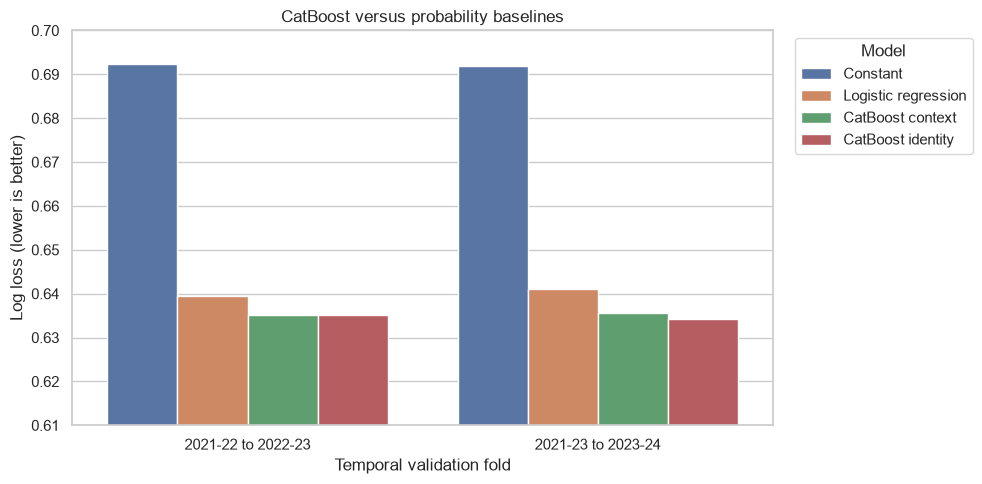

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=model_results, x="fold", y="log_loss", hue="model")
plt.ylim(0.61, 0.70)
plt.xlabel("Temporal validation fold")
plt.ylabel("Log loss (lower is better)")
plt.title("CatBoost versus probability baselines")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Feature-importance sanity check

CatBoost importance shows which inputs the fitted model used most, but it does not establish causal effects. The next notebook checks performance across basketball segments.

In [7]:
latest_artifact = fold_artifacts[latest_fold["fold"]]
importance_records = []
for variant_name, model in [
    ("Context", latest_artifact["context_model"]),
    ("Identity", latest_artifact["identity_model"]),
]:
    for feature_name, importance in zip(model.feature_names_, model.get_feature_importance()):
        importance_records.append(
            {"variant": variant_name, "feature": feature_name, "importance": importance}
        )

importance_table = pd.DataFrame(importance_records)
importance_table.sort_values(["variant", "importance"], ascending=[True, False]).groupby(
    "variant", group_keys=False
).head(10)

,variant,feature,importance
11,Context,action_type,41.68296
1,Context,shot_distance_squared,12.43707
0,Context,shot_distance_feet,11.17455
4,Context,abs_loc_x_feet,5.33969
3,Context,loc_y_feet,5.27148
7,Context,seconds_remaining_in_period,5.12193
13,Context,shot_zone_basic,5.01363
5,Context,shot_angle_degrees,4.44713
2,Context,loc_x_feet,2.45412
15,Context,shot_zone_range,1.92918


## 6. CatBoost results

- Depth 5 was selected. On the latest development fold it achieved 0.63558 log loss versus 0.63570 for depth 7, so the deeper model did not earn its added complexity.
- Context-only CatBoost improved on logistic regression in both folds, reducing log loss by 0.00441 and 0.00552. It also improved Brier score and ECE in both folds.
- Adding player and team identity improved context-only CatBoost log loss by 0.00010 and 0.00127. The mean gain of 0.00068 exceeds the pre-declared 0.00050 threshold, so the identity variant is accepted under the primary selection rule.
- The selected identity model achieved log losses of 0.63504 and 0.63432, with Brier scores of 0.22333 and 0.22306. Its best iterations were 211 and 612.
- Identity creates a calibration tradeoff: ECE increased to 0.01617 and 0.01183, compared with 0.00938 and 0.00562 for context-only CatBoost. The diagnostics notebook will inspect this by probability bin and basketball segment.
- Action type and distance dominate both models. Player ID has meaningful but secondary importance in the identity model; feature importance is descriptive, not causal.
- No final-holdout result influenced depth, early stopping, or the identity decision.